# Profile the soft-clip of alignments

In [3]:
from collections import defaultdict
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
runs = [
    "20220719_K562_1", 
    "20220719_K562_2", 
    "20220719_K562_3", 
    "20220719_K562_4", 
    "20220729_K562_1", 
    "20220729_K562_2"
]

## Number of soft-clip at aligments (errorbar)

In [9]:
vmax = 10
array1 = []
array2 = []
for run in runs:
    for cell in info[info["Run"] == run].index:
        path = "../../../1_NanoNASCseq/results/3_mapping/4_stat_clip/%s/%s.tsv" % (run, cell)
        d = pd.read_csv(path, sep="\t", header=0)
        counter1 = defaultdict(int)
        counter2 = defaultdict(int)
        for c1, c2, count in d[["HeadClip", "TailClip", "Count"]].values:
            counter1[min(c1, vmax)] += count
            counter2[min(c2, vmax)] += count
        array1.append([counter1[i] for i in range(vmax+1)])
        array2.append([counter2[i] for i in range(vmax+1)])

In [26]:
m1 = pd.DataFrame(array1)
m1 = m1.divide(m1.sum(axis=1), axis=0)
m2 = pd.DataFrame(array2)
m2 = m2.divide(m2.sum(axis=1), axis=0)
m = pd.DataFrame({
    "Mean.5": m1.mean(axis=0),
    "Std.5": m1.std(axis=0),
    "Size.5": m1.shape[0],
    "Mean.3": m2.mean(axis=0),
    "Std.3": m2.std(),
    "Size.3": m2.shape[0]
})
m.index = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, "ge10"]
m.index.name = "Clip"
m.to_csv("results/soft_clip.stats.csv")
m

,Mean.5,Std.5,Size.5,Mean.3,Std.3,Size.3
Clip,,,,,,
0,0.629002,0.042940,438,0.890181,0.015805,438
1,0.204221,0.044411,438,0.018155,0.002716,438
2,0.030636,0.004506,438,0.013166,0.002719,438
3,0.022364,0.003214,438,0.012008,0.002634,438
4,0.013646,0.001992,438,0.006338,0.001337,438
5,0.009994,0.002154,438,0.005566,0.002256,438
6,0.008687,0.001650,438,0.004300,0.001221,438
7,0.006799,0.001388,438,0.003057,0.000738,438
8,0.005778,0.001374,438,0.002757,0.000817,438


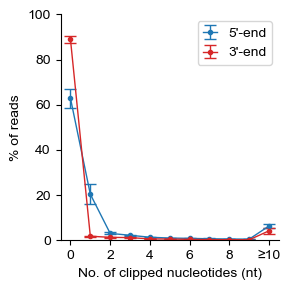

In [29]:
m = pd.read_csv("results/soft_clip.stats.csv", index_col=0)
xs = np.arange(m.shape[0])
plt.figure(figsize=(3, 3))
plt.errorbar(xs, m["Mean.5"]*100, yerr=m["Std.5"]*100, marker=".", lw=1, capsize=4, capthick=1, color="C0", label="5'-end")
plt.errorbar(xs, m["Mean.3"]*100, yerr=m["Std.3"]*100, marker=".", lw=1, capsize=4, capthick=1, color="C3", label="3'-end")
plt.xticks([0, 2, 4, 6, 8, 10], ["0", "2", "4", "6", "8", "≥10"])
plt.ylim(0, 100)
plt.xlabel("No. of clipped nucleotides (nt)")
plt.ylabel("% of reads")
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(frameon=True, handlelength=1)
plt.tight_layout()
plt.savefig("figures/stat_clip.errorbar.pdf")
plt.show()
plt.close()

## Proportion of reads pass filtering (pie)

In [31]:
rows = []
for run in runs:
    for cell in info[info["Run"] == run].index:
        path = "../../../1_NanoNASCseq/results/3_mapping/4_stat_clip/%s/%s.log" % (run, cell)
        n1, n2, n3 = open(path).readlines()[-1].strip().split("\t")
        n1, n2, n3 = int(n1), int(n2), float(n3)
        rows.append([n1, n2, n3])
m = pd.DataFrame(rows, columns=["Input", "Output", "Pass"])
m

,Input,Output,Pass
0,127174,121576,0.955982
1,118757,111250,0.936787
2,129604,121018,0.933752
3,175720,161872,0.921193
4,180954,173384,0.958166
...,...,...,...
433,225726,217552,0.963788
434,212988,202292,0.949781
435,330350,313843,0.950032
436,262308,248707,0.948149


In [34]:
mean, std = m["Pass"].mean(), m["Pass"].std()
print("Mean:", mean)
print("Std:", std)

Mean: 0.9402561529680364
Std: 0.01916049039699754


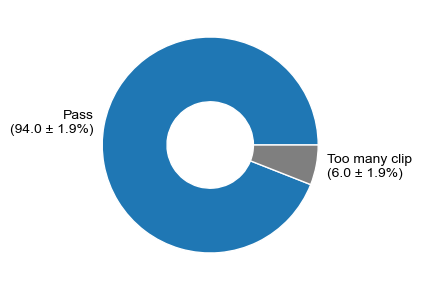

In [ ]:
plt.figure(figsize=(4.5, 3))
plt.pie([mean, 1 - mean], 
        labels=["Pass\n(%.1f ± %.1f%%)" % (mean * 100, std * 100), 
                "Too many clip\n(%.1f ± %.1f%%)" % ((1 - mean) * 100, std * 100)],
        colors=["C0", "C7"], 
        wedgeprops=dict(width=0.6, edgecolor='w'))
plt.tight_layout()
plt.savefig("figures/stat_clip.pie.pdf")
plt.show()
plt.close()